# Exploratory Data Analysis - Elliptic Dataset

This notebook provides an overview of the Elliptic dataset used for AML detection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Ensure project root is in sys.path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.infrastructure.config import config
from src.infrastructure.storage import storage
from src.use_cases.data_ingestion import DataIngestion
from src.use_cases.feature_engineering import FeatureEngineering

sns.set_theme(style="whitegrid")

## 1. Data Ingestion

Loading the raw data and performing initial cleaning.

In [2]:
ingestion = DataIngestion()
raw_data = ingestion.ingest_raw_data()
df = ingestion.clean_and_merge(raw_data)
df.head()

[2026-02-25 15:47:33.659] [    INFO] [src.use_cases.data_ingestion] Starting raw data ingestion | {'taskName': 'Task-30'}
[2026-02-25 15:47:41.406] [    INFO] [src.infrastructure.storage] Successfully loaded CSV file | {'taskName': 'Task-30', 'path': 'c:\\Users\\Thiago\\Documents\\code\\aml-gnn\\data\\raw\\elliptic_txs_features.csv', 'rows': 203769}
[2026-02-25 15:47:41.408] [    INFO] [src.infrastructure.storage] Completed: DiskStorage.load_csv (took 7747.6ms) | {'taskName': 'Task-30'}
[2026-02-25 15:47:41.471] [    INFO] [src.infrastructure.storage] Successfully loaded CSV file | {'taskName': 'Task-30', 'path': 'c:\\Users\\Thiago\\Documents\\code\\aml-gnn\\data\\raw\\elliptic_txs_classes.csv', 'rows': 203769}
[2026-02-25 15:47:41.471] [    INFO] [src.infrastructure.storage] Completed: DiskStorage.load_csv (took 62.9ms) | {'taskName': 'Task-30'}
[2026-02-25 15:47:41.545] [    INFO] [src.infrastructure.storage] Successfully loaded CSV file | {'taskName': 'Task-30', 'path': 'c:\\Users\\

,txId,timestep,2,3,4,5,6,7,8,9,...,158,159,160,161,162,163,164,165,166,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,-1
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,-1
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,-1
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,0
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,-1


## 2. Label Distribution

Understanding the class imbalance (illicit vs lawful vs unknown).

C:\Users\Thiago\AppData\Local\Temp\ipykernel_35088\4120484360.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


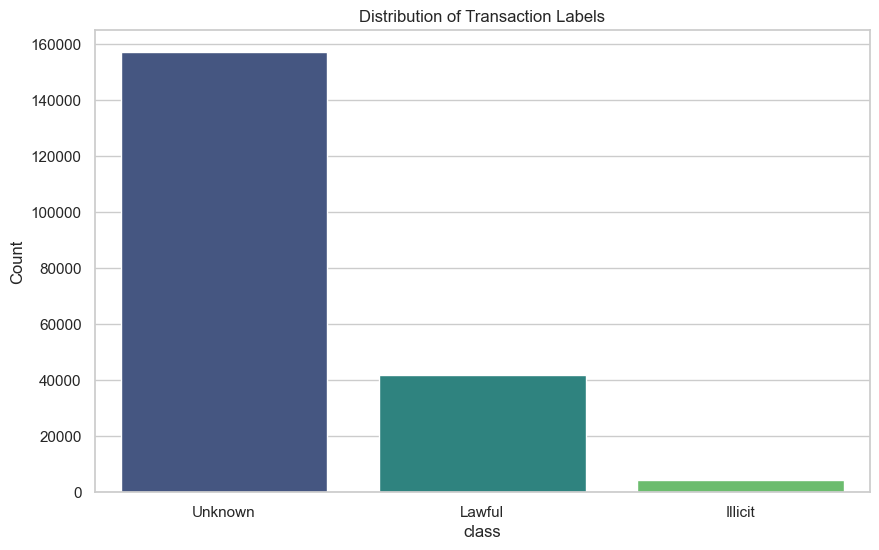

Percentages:
class
-1    77.148634
 0    20.620899
 1     2.230467
Name: proportion, dtype: float64


In [3]:
label_counts = df['class'].value_counts().sort_index()
label_names = {1: 'Illicit', 0: 'Lawful', -1: 'Unknown'}
label_counts.index = label_counts.index.map(label_names)

plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribution of Transaction Labels')
plt.ylabel('Count')
plt.show()

print("Percentages:")
print(df['class'].value_counts(normalize=True) * 100)

## 3. Temporal Analysis

Transactions are distributed across 49 time steps.

[2026-02-25 15:47:59.393] [    INFO] [matplotlib.category] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting. | {'taskName': 'Task-36'}
C:\Users\Thiago\AppData\Local\Temp\ipykernel_35088\3926551614.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='timestep', palette='magma')
[2026-02-25 15:47:59.551] [    INFO] [matplotlib.category] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting. | {'taskName': 'Task-36'}


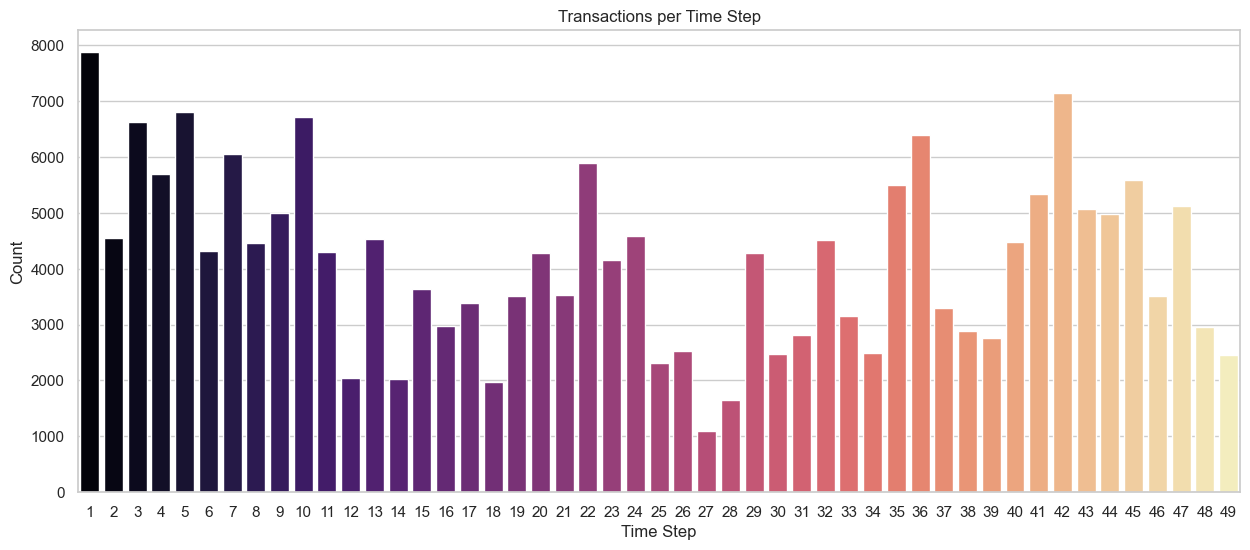

In [4]:
plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='timestep', palette='magma')
plt.title('Transactions per Time Step')
plt.xlabel('Time Step')
plt.ylabel('Count')
plt.show()

## 4. Feature Engineering

Scaling features and performing temporal splitting.

In [5]:
fe = FeatureEngineering()
df_scaled = fe.scale_features(df.copy())
train, val, test = fe.temporal_split(df_scaled)

print(f"Train size: {len(train)}")
print(f"Val size: {len(val)}")
print(f"Test size: {len(test)}")

[2026-02-25 15:48:03.920] [    INFO] [src.use_cases.feature_engineering] Scaling features | {'taskName': 'Task-39', 'num_features': 165}
[2026-02-25 15:48:04.864] [    INFO] [src.use_cases.feature_engineering] Feature scaling completed | {'taskName': 'Task-39'}
[2026-02-25 15:48:04.865] [    INFO] [src.use_cases.feature_engineering] Completed: FeatureEngineering.scale_features (took 945.0ms) | {'taskName': 'Task-39'}
[2026-02-25 15:48:05.141] [    INFO] [src.use_cases.feature_engineering] Temporal split completed | {'taskName': 'Task-39', 'train': 136265, 'val': 37820, 'test': 29684}
[2026-02-25 15:48:05.143] [    INFO] [src.use_cases.feature_engineering] Completed: FeatureEngineering.temporal_split (took 276.2ms) | {'taskName': 'Task-39'}


Train size: 136265
Val size: 37820
Test size: 29684
